In [1]:
import numpy as np
from numpy import pi

def generate_spiral(a, b, N, noise_factor=0):

    theta = np.sqrt(np.random.rand(N))*4*pi
    r = a + b*theta
    x = np.array([np.cos(theta)*r, np.sin(theta)*r]).T
    x += np.expand_dims(noise_factor*r,1)*np.random.randn(N,2)
    return x

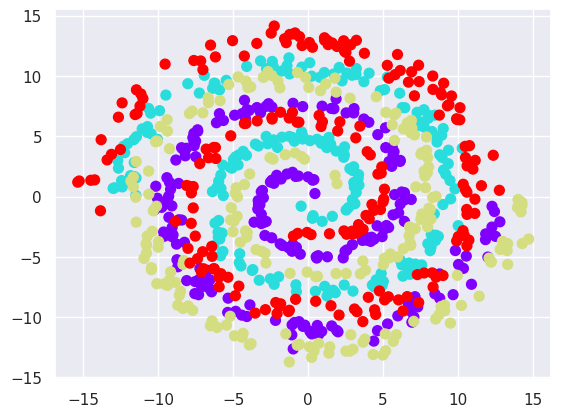

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

N = 200
a = 1.75
b = 1
noise_factor = 0.05

x1 = generate_spiral(0,b,N,noise_factor)
x2 = generate_spiral(0,-b,N,noise_factor)
x3 = generate_spiral(a,b,N,noise_factor)
x4 = generate_spiral(-a,-b,N,noise_factor)

X = np.concatenate((x1,x2,x3,x4),axis=0)
Y = np.ravel(np.concatenate((np.zeros((N,1)),np.ones((N,1)),2*np.ones((N,1)),3*np.ones((N,1))), axis=0))


plt.scatter(X[:, 0], X[:, 1], c=Y, s=50, cmap='rainbow');

# **Actividad 1**
Como primera actividad de la tarea deberás dividir el conjunto de datos en subconjuntos de entrenamiento y prueba, utilizando la función train_test_split de sklearn, con una proporción adecuada para cada uno, dado el tamaño del conjunto de datos.

## **Desarrollo**

En este caso opté por dividir los datos en 80% para entrenamiento y 20% para prueba porque el conjunto de datos es relativamente pequeño y el problema de clasificar espirales es complejo. Al usar el 80% para entrenamiento, el modelo tendrá suficiente información para aprender patrones no lineales, mientras que el 20% de prueba nos permitirá evaluar bien su rendimiento y detectar si está sobreajustando sin que falten datos para entrenar. en la información que he consultado sobre problemas similares esta proporción es una práctica común y equilibrada.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Tamaño del conjunto de entrenamiento:", X_train.shape[0])
print("Tamaño del conjunto de prueba:", X_test.shape[0])


Tamaño del conjunto de entrenamiento: 640
Tamaño del conjunto de prueba: 160


# **Actividad 2:**

Entrena al menos 3 modelos basados en las técnicas cubiertas en el módulo 2 del curso. Para cada una, obtenga su rendimiento en los conjuntos de entrenamiento y prueba y comente sobre el nivel de sobreajuste exhibido, en función de la comparación entre modelos.



In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# 1. Modelo K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
train_accuracy_knn = accuracy_score(y_train, knn.predict(X_train))
test_accuracy_knn = accuracy_score(y_test, knn.predict(X_test))

# 2. Modelo Decision Tree
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
train_accuracy_tree = accuracy_score(y_train, tree.predict(X_train))
test_accuracy_tree = accuracy_score(y_test, tree.predict(X_test))

# 3. Modelo Random Forest
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train, y_train)
train_accuracy_rf = accuracy_score(y_train, random_forest.predict(X_train))
test_accuracy_rf = accuracy_score(y_test, random_forest.predict(X_test))

# 4. Modelo Gradient Boosting
gradient_boosting = GradientBoostingClassifier(random_state=42)
gradient_boosting.fit(X_train, y_train)
train_accuracy_gb = accuracy_score(y_train, gradient_boosting.predict(X_train))
test_accuracy_gb = accuracy_score(y_test, gradient_boosting.predict(X_test))


print("Precisión KNN - Entrenamiento:", train_accuracy_knn, "Prueba:", test_accuracy_knn)
print("Precisión Decision Tree - Entrenamiento:", train_accuracy_tree, "Prueba:", test_accuracy_tree)
print("Precisión Random Forest - Entrenamiento:", train_accuracy_rf, "Prueba:", test_accuracy_rf)
print("Precisión Gradient Boosting - Entrenamiento:", train_accuracy_gb, "Prueba:", test_accuracy_gb)



Precisión KNN - Entrenamiento: 0.9171875 Prueba: 0.8375
Precisión Decision Tree - Entrenamiento: 1.0 Prueba: 0.775
Precisión Random Forest - Entrenamiento: 1.0 Prueba: 0.8125
Precisión Gradient Boosting - Entrenamiento: 0.9421875 Prueba: 0.69375


## **Comentarios**

**KNN** tiene una precisión bastante cercana en entrenamiento (91.7%) y prueba (83.8%), lo cual indica que generaliza bien y tiene un bajo nivel de sobreajuste. Es el modelo que mejor logra capturar los patrones del conjunto de datos sin memorizar excesivamente los detalles del entrenamiento.

**Decision Tree** está claramente sobreajustado, ya que alcanza el 100% de precisión en entrenamiento pero cae a 77.5% en prueba. Esto significa que ha aprendido demasiado los detalles específicos del entrenamiento, lo que limita su capacidad para generalizar a datos nuevos.

**Random Forest** también muestra sobreajuste, aunque menos que Decision Tree. Aunque logra 100% en entrenamiento, su precisión en prueba es mejor que la de Decision Tree (81.3%), lo que indica que el promedio entre múltiples árboles ayuda a reducir el sobreajuste, aunque aún es evidente.

**Gradient Boosting** también tiene un nivel significativo de sobreajuste, con una precisión de 94.2% en entrenamiento y 69.4% en prueba. La caída en precisión entre los dos conjuntos sugiere que está aprendiendo patrones específicos del entrenamiento que no generalizan bien.

Para reducir el sobreajuste en Decision Tree, Random Forest y Gradient Boosting, podríamos limitar la profundidad de los árboles, ajustar el mínimo de muestras por hoja o bajar la tasa de aprendizaje en Gradient Boosting.

# **Actividad 3**

Visualiza las superficies de decisión de cada uno de los modelos entrenados, utilizando el esquema presentado en los tutoriales, e identifique los sectores del espacio de características donde se aprecie sobreajuste. Comente sobre las características de estos sectores para cada modelo.

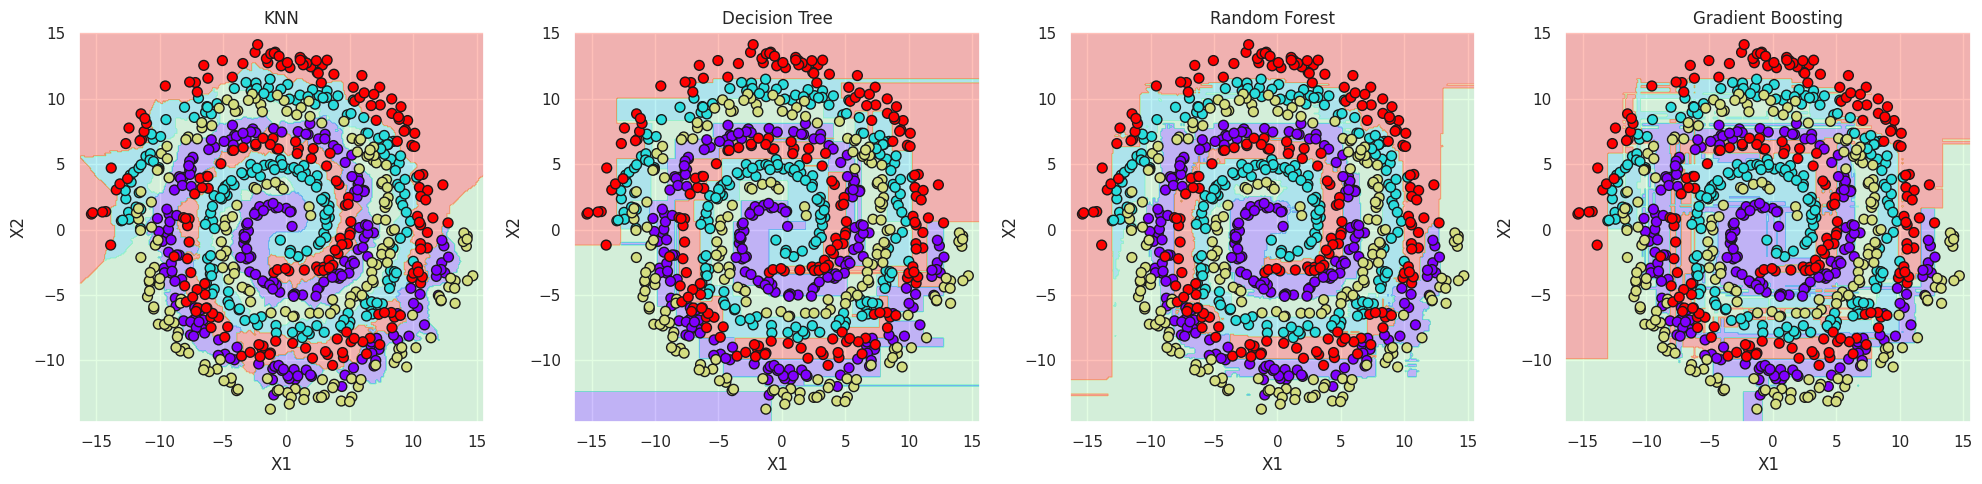

In [13]:
import numpy as np
import matplotlib.pyplot as plt


x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

def plot_decision_boundary(model, title, ax):

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)


    ax.contourf(xx, yy, Z, alpha=0.3, cmap='rainbow')
    ax.scatter(X[:, 0], X[:, 1], c=Y, s=50, cmap='rainbow', edgecolor='k')
    ax.set_title(title)
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")


fig, axs = plt.subplots(1, 4, figsize=(20, 5))


plot_decision_boundary(knn, "KNN", axs[0])
plot_decision_boundary(tree, "Decision Tree", axs[1])
plot_decision_boundary(random_forest, "Random Forest", axs[2])
plot_decision_boundary(gradient_boosting, "Gradient Boosting", axs[3])


plt.tight_layout()
plt.show()




## **Comentarios**

**Análisis de los graficos:**

**KNN:**

*   Tiene límites suaves y continuos, lo que indica buena generalización.
*   En el caso de K-Nearest Neighbors (KNN), no se observan sectores claros de sobreajuste. La superficie de decisión es continua y suave, siguiendo el patrón general de las espirales sin crear divisiones complejas o fragmentadas. Esto sugiere que KNN generaliza bien y no memoriza los detalles específicos del conjunto de entrenamiento.

**Decision Tree:**

*   Las divisiones cuadradas y abruptas dentro de las regiones muestran un alto sobreajuste, ya que el modelo intenta capturar cada punto específico.
*   Para Decision Tree, el sobreajuste es evidente en todo el espacio, especialmente en los bordes de las espirales y en las áreas donde cambian de dirección o se acercan unas a otras. Estas zonas muestran muchas divisiones rectangulares y pequeñas, lo cual indica que el árbol intenta adaptar su límite de decisión a cada punto de entrenamiento, creando una superficie demasiado compleja y específica.

**Random Forest:**

*   Reduce la fragmentación, pero aún presenta divisiones en zonas exteriores y entre espirales, lo cual es señal de un sobreajuste moderado.

*   En Random Forest, aunque el sobreajuste es menor que en el árbol de decisión individual, aún se observan fragmentaciones en los bordes de las espirales y en las zonas donde las espirales están muy cerca. Esto indica que el modelo intenta capturar detalles específicos en estas áreas, aunque de manera más moderada, gracias al efecto de promedio entre los árboles del bosque.


**Gradient Boosting:**

*   Presenta fragmentación en los bordes y áreas de intersección, lo que indica que intenta capturar detalles adicionales, con cierto sobreajuste.
*   Por último, Gradient Boosting muestra sobreajuste en los límites de las clases y en las zonas exteriores de las espirales, donde intenta capturar patrones adicionales. Las áreas de fragmentación son más visibles en los bordes y en las zonas donde las espirales se intersecan o están muy cercanas, lo que indica que el modelo se adapta en exceso a los detalles del conjunto de entrenamiento.














# **Actividad 4**
Realiza un análisis de sensibilidad de los modelos con respecto a las características de los datos. Para esto, modifique el conjunto de datos utilizando los parámetros que recibe la función que genera espirales. Específicamente, estudie el efecto del ruido y de la forma de las espirales.

## **Desarrollo**

Para este ejercicio voy a probar dos experimentos:

1. Aumentar el nivel de ruido para ver cómo los modelos se comportan con datos más dispersos.
2. Modificar los parámetros de forma (a y b) para cambiar la estructura de las espirales.



In [15]:
## Generando diferentes conjuntos de datos

N = 200

noise_levels = [0.05, 0.2, 0.5]
shape_params = [(1.5, 1), (1, 0.5), (2, 1.5)]

def generate_data_with_params(a, b, noise_factor):
    x1 = generate_spiral(0, b, N, noise_factor)
    x2 = generate_spiral(0, -b, N, noise_factor)
    x3 = generate_spiral(a, b, N, noise_factor)
    x4 = generate_spiral(-a, -b, N, noise_factor)
    X_data = np.concatenate((x1, x2, x3, x4), axis=0)
    Y_data = np.ravel(np.concatenate((np.zeros((N,1)), np.ones((N,1)),
                                      2*np.ones((N,1)), 3*np.ones((N,1))), axis=0))
    return X_data, Y_data


In [19]:
# Entrenando y evaluando diferentes configuraciones
import pandas as pd
from sklearn.metrics import accuracy_score

results = []

for noise in noise_levels:
    X_noisy, Y_noisy = generate_data_with_params(1.75, 1, noise)
    X_train, X_test, y_train, y_test = train_test_split(X_noisy, Y_noisy, test_size=0.2, random_state=42)


    knn.fit(X_train, y_train)
    tree.fit(X_train, y_train)
    random_forest.fit(X_train, y_train)
    gradient_boosting.fit(X_train, y_train)

    results.append({
        'config': f'Noise={noise}',
        'KNN_train': accuracy_score(y_train, knn.predict(X_train)),
        'KNN_test': accuracy_score(y_test, knn.predict(X_test)),
        'Tree_train': accuracy_score(y_train, tree.predict(X_train)),
        'Tree_test': accuracy_score(y_test, tree.predict(X_test)),
        'RF_train': accuracy_score(y_train, random_forest.predict(X_train)),
        'RF_test': accuracy_score(y_test, random_forest.predict(X_test)),
        'GB_train': accuracy_score(y_train, gradient_boosting.predict(X_train)),
        'GB_test': accuracy_score(y_test, gradient_boosting.predict(X_test))
    })


for a, b in shape_params:
    X_shaped, Y_shaped = generate_data_with_params(a, b, 0.05)
    X_train, X_test, y_train, y_test = train_test_split(X_shaped, Y_shaped, test_size=0.2, random_state=42)


    knn.fit(X_train, y_train)
    tree.fit(X_train, y_train)
    random_forest.fit(X_train, y_train)
    gradient_boosting.fit(X_train, y_train)

    results.append({
        'config': f'Shape_a={a}_b={b}',
        'KNN_train': accuracy_score(y_train, knn.predict(X_train)),
        'KNN_test': accuracy_score(y_test, knn.predict(X_test)),
        'Tree_train': accuracy_score(y_train, tree.predict(X_train)),
        'Tree_test': accuracy_score(y_test, tree.predict(X_test)),
        'RF_train': accuracy_score(y_train, random_forest.predict(X_train)),
        'RF_test': accuracy_score(y_test, random_forest.predict(X_test)),
        'GB_train': accuracy_score(y_train, gradient_boosting.predict(X_train)),
        'GB_test': accuracy_score(y_test, gradient_boosting.predict(X_test))
    })

df_results = pd.DataFrame(results)
print(df_results)


            config  KNN_train  KNN_test  Tree_train  Tree_test  RF_train  \
0       Noise=0.05   0.887500   0.77500         1.0    0.76875       1.0   
1        Noise=0.2   0.600000   0.39375         1.0    0.38750       1.0   
2        Noise=0.5   0.525000   0.33125         1.0    0.31250       1.0   
3  Shape_a=1.5_b=1   0.884375   0.76875         1.0    0.80000       1.0   
4  Shape_a=1_b=0.5   0.879687   0.78125         1.0    0.76250       1.0   
5  Shape_a=2_b=1.5   0.887500   0.71875         1.0    0.73125       1.0   

   RF_test  GB_train  GB_test  
0  0.77500  0.929688  0.64375  
1  0.40625  0.820312  0.39375  
2  0.30000  0.810937  0.28125  
3  0.81250  0.918750  0.61250  
4  0.77500  0.918750  0.58750  
5  0.73750  0.906250  0.56875  


## **Análisis del efecto del ruido y de la forma de las espirales**

Con bajo ruido ***(Noise=0.05)***,  todos los modelos funcionan bastante bien en general, aunque Decision Tree y Random Forest tienden a sobreajustarse, alcanzando 100% en entrenamiento pero menos en prueba. KNN muestra un buen equilibrio entre entrenamiento y prueba, lo que indica que generaliza bien. Gradient Boosting también logra alta precisión en entrenamiento, pero su precisión en prueba es menor, lo que sugiere un leve sobreajuste.

A medida que aumentamos el ruido ***(Noise=0.2 y Noise=0.5)***, todos los modelos ven una caída significativa en precisión. KNN es el más afectado, y su precisión baja bastante en prueba. Decision Tree y Random Forest se mantienen en 100% en entrenamiento, pero su rendimiento en prueba cae drásticamente, mostrando un fuerte sobreajuste. Gradient Boosting también sufre con el ruido, y su precisión en prueba baja considerablemente, indicando que el modelo tiene problemas para generalizar cuando los datos tienen mucho ruido.

Al cambiar la forma de las espirales, KNN sigue siendo el modelo más robusto. Con diferentes configuraciones de forma ***(Shape_a=1.5, b=1, Shape_a=1, b=0.5, y Shape_a=2, b=1.5)***, KNN mantiene un buen rendimiento en prueba, mostrando que se adapta bien a estos cambios sin sobreajustarse. Decision Tree y Random Forest tienden a mantener el 100% en entrenamiento y algo menos en prueba, indicando que aún muestran cierto nivel de sobreajuste. Gradient Boosting es el más sensible a los cambios en la forma, mostrando una caída considerable en prueba, lo que indica que le cuesta generalizar en estas configuraciones.

Podemos entonces indicar que **KNN es el modelo que mejor generaliza y es más estable frente a cambios en ruido y forma.** Decision Tree y Random Forest tienden a sobreajustarse, especialmente con ruido alto. Gradient Boosting es el modelo más sensible, mostrando un rendimiento inestable con ruido y cambios de forma.


# **Interpretacion de los resultados un poco más detallado:**

### **1. Efecto del ruido en los modelos**
---
***Noise=0.05 (bajo ruido)***


**KNN:** Tiene una buena precisión en entrenamiento (88.8%) y prueba (77.5%), lo que sugiere que el modelo está generalizando bien con bajo nivel de ruido.

**Decision Tree:** La precisión en entrenamiento es del 100% (indicativo de sobreajuste), mientras que en prueba baja a 76.9%, lo que muestra un nivel de sobreajuste moderado.

**Random Forest:** Similar a Decision Tree, tiene una precisión perfecta en entrenamiento pero 77.5% en prueba, lo que indica cierto sobreajuste, aunque menos pronunciado que en el árbol de decisión.

**Gradient Boosting:** La precisión en entrenamiento es alta (92.9%) pero baja en prueba (64.4%), lo cual sugiere sobreajuste también. Gradient Boosting parece ser más sensible al ruido que KNN y Random Forest, probablemente debido a su enfoque secuencial.

---

***Noise=0.2 (ruido moderado)***

**KNN:** La precisión baja significativamente (60% en entrenamiento y 39.4% en prueba), lo cual indica que el modelo está teniendo problemas para capturar la estructura de los datos con mayor ruido.

**Decision Tree:** Permanece con 100% en entrenamiento, pero la precisión en prueba cae drásticamente a 38.8%, lo que muestra un alto nivel de sobreajuste. El árbol de decisión intenta ajustar cada punto, incluso con el ruido, lo que lo hace menos efectivo.

**Random Forest:** Aunque mantiene el 100% en entrenamiento, la precisión en prueba cae a 40.6%, mostrando sobreajuste. El ruido está afectando la capacidad de generalización del modelo.

**Gradient Boosting:** La precisión en entrenamiento es 82%, y en prueba cae a 39.4%, lo que indica un fuerte sobreajuste. Gradient Boosting se ve afectado considerablemente por el ruido, similar a Random Forest y Decision Tree.


---

***Noise=0.5 (ruido alto)***

**KNN:** La precisión sigue disminuyendo (52.5% en entrenamiento y 33.1% en prueba), indicando que KNN no está capturando bien la estructura en un entorno de ruido elevado.

**Decision Tree:** La precisión en entrenamiento sigue en 100%, pero en prueba cae a 31.3%, lo que sugiere que el modelo está completamente sobreajustado y no es capaz de generalizar bien con tanto ruido.

**Random Forest:** Similar al árbol de decisión, su precisión en prueba baja a 30%, indicando que está sobreajustando en gran medida con ruido alto.

**Gradient Boosting:** La precisión en entrenamiento baja a 81%, y en prueba a 28.1%, mostrando que el modelo se está ajustando demasiado a los datos ruidosos sin generalizar bien.
Efecto de la forma de las espirales en los modelos

---


 ### **2. Interpretación de los resultasos de la Modificación de los parámetros de forma (a y b) y cambio de la estructura de las espirales.**
---

### **Shape_a=1.5, b=1 (espirales con separación moderada)**





**KNN:** La precisión es alta en entrenamiento (88.4%) y razonable en prueba (76.9%), lo que indica que el modelo está generalizando bien con esta configuración de forma.

**Decision Tree:** Mantiene el 100% en entrenamiento y una precisión relativamente alta en prueba (80%), lo que sugiere sobreajuste, aunque es capaz de generalizar mejor con esta configuración.

**Random Forest:** Alcanza el 100% en entrenamiento y 81.3% en prueba, mostrando que Random Forest maneja esta forma bastante bien, aunque aún presenta algo de sobreajuste.

**Gradient Boosting:** Tiene una precisión alta en entrenamiento (91.9%) y una caída en prueba (61.3%), lo que indica cierto sobreajuste.

---
### **Shape_a=1, b=0.5 (espirales más estrechas)**


**KNN:** La precisión sigue siendo buena (87.9% en entrenamiento y 78.1% en prueba), lo que indica que KNN es robusto frente a esta variación de forma.

**Decision Tree:**  Mantiene el 100% en entrenamiento y 76.3% en prueba, lo que muestra sobreajuste.

**Random Forest:** Muestra un rendimiento similar con 100% en entrenamiento y 77.5% en prueba, indicando sobreajuste, pero menor que en Decision Tree.

**Gradient Boosting:** La precisión en entrenamiento es de 91.9%, y en prueba baja a 58.8%, lo que sugiere que Gradient Boosting tiene más problemas para generalizar con esta configuración.

----
### **Shape_a=2, b=1.5 (espirales más anchas)**

**KNN:** La precisión baja ligeramente en prueba (88.8% en entrenamiento, 71.9% en prueba), lo que sugiere que KNN tiene un leve impacto con esta configuración.

**Decision Tree:**  Sigue mostrando sobreajuste con 100% en entrenamiento y 73.1% en prueba.

**Random Forest:** Alcanza 100% en entrenamiento y 73.8% en prueba, indicando que el modelo sigue siendo algo robusto, pero aún tiene sobreajuste.

**Gradient Boosting:** Tiene 90.6% en entrenamiento y 56.9% en prueba, mostrando que Gradient Boosting es el más afectado por esta variación de forma.

# **Anexo1:Gráficos de los resultados de precisión de cada modelo en función de las distintas configuraciones de ruido y forma de las espirales.**

Hago esto como un análisis extra que me ayuda a visualizar cómo cada modelo responde a los cambios en las características del conjunto de datos ya que la interpretación visual de las gráficas refuerza y confirma este análisis previo.

En nuestro este caso tanto el analisis anterior coincide con las gráficas presentadas aqui acontinuacion, pues ambos concluyen de manera coherente que KNN es el modelo que mejor generaliza y es más estable frente a cambios en ruido y forma. Mientras que Decision Tree y Random Forest tienden a sobreajustarse, especialmente con alto ruido, mientras que Gradient Boosting es el modelo más sensible y muestra un rendimiento inestable con cambios en ruido y forma.

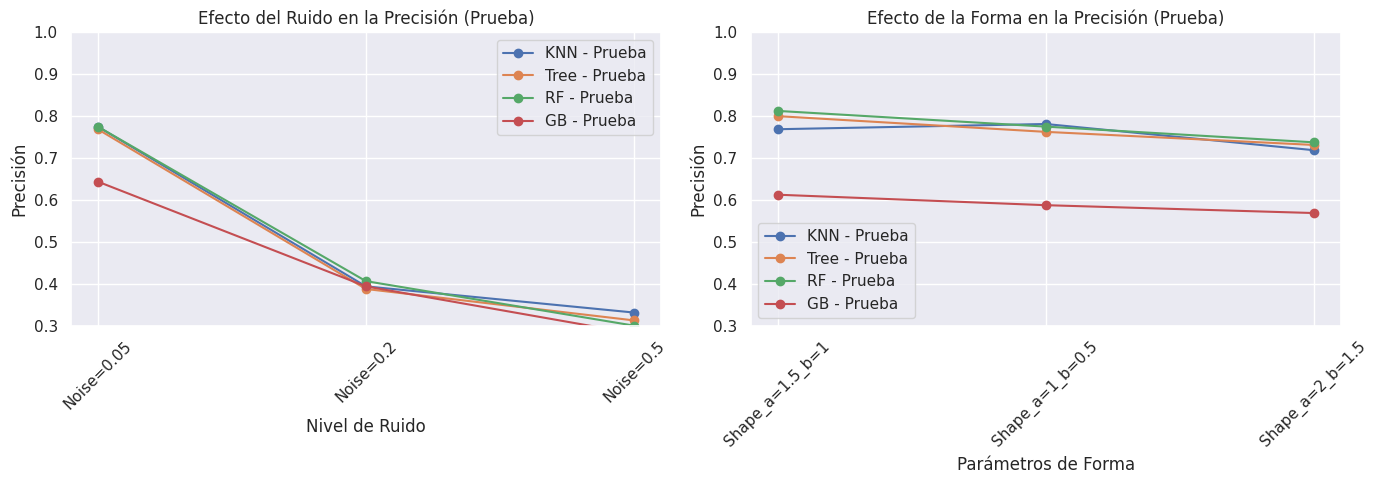

In [29]:
#Grafico del análisis anterior para prueba

import matplotlib.pyplot as plt



# Efecto del ruido en el conjunto de prueba
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for model in ['KNN', 'Tree', 'RF', 'GB']:
    plt.plot(noise_data['config'], noise_data[f'{model}_test'], label=f'{model} - Prueba', marker='o')
plt.title('Efecto del Ruido en la Precisión (Prueba)')
plt.xlabel('Nivel de Ruido')
plt.ylabel('Precisión')
plt.ylim(0.3, 1.0)
plt.legend()
plt.xticks(rotation=45)

# Efecto de la forma de las espirales en el conjunto de prueba
plt.subplot(1, 2, 2)
for model in ['KNN', 'Tree', 'RF', 'GB']:
    plt.plot(shape_data['config'], shape_data[f'{model}_test'], label=f'{model} - Prueba', marker='o')
plt.title('Efecto de la Forma en la Precisión (Prueba)')
plt.xlabel('Parámetros de Forma')
plt.ylabel('Precisión')
plt.ylim(0.3, 1.0)
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()





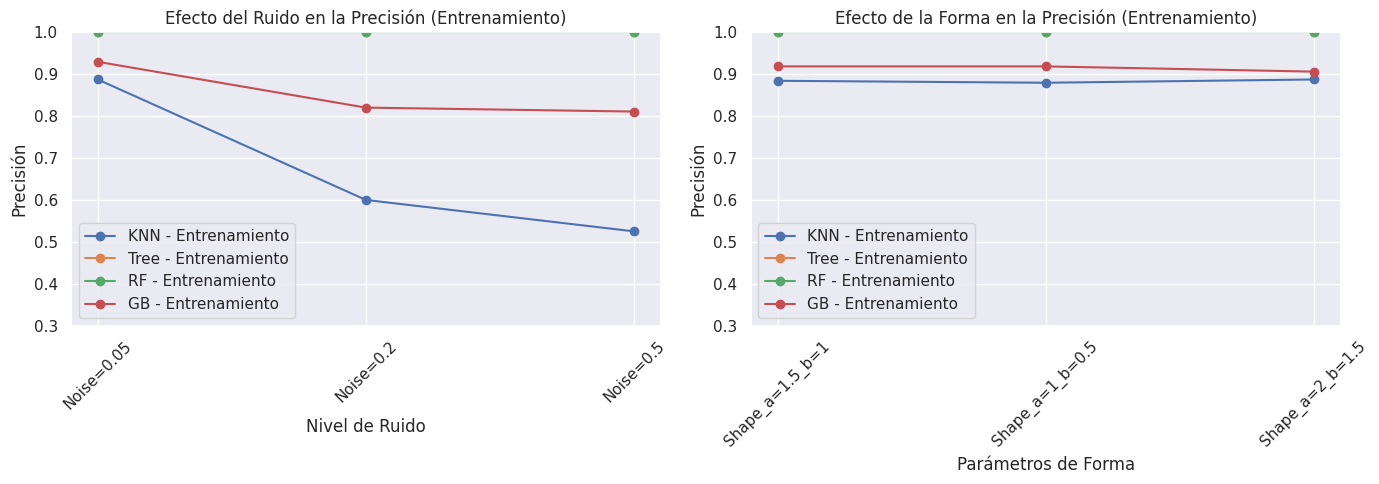

In [30]:
# Gráficas separadas para entrenamiento

import matplotlib.pyplot as plt



plt.figure(figsize=(14, 5))

# Efecto del ruido en el conjunto de entrenamiento
plt.subplot(1, 2, 1)
for model in ['KNN', 'Tree', 'RF', 'GB']:
    plt.plot(noise_data['config'], noise_data[f'{model}_train'], label=f'{model} - Entrenamiento', marker='o')
plt.title('Efecto del Ruido en la Precisión (Entrenamiento)')
plt.xlabel('Nivel de Ruido')
plt.ylabel('Precisión')
plt.ylim(0.3, 1.0)
plt.legend()
plt.xticks(rotation=45)

# Efecto de la forma de las espirales en el conjunto de entrenamiento
plt.subplot(1, 2, 2)
for model in ['KNN', 'Tree', 'RF', 'GB']:
    plt.plot(shape_data['config'], shape_data[f'{model}_train'], label=f'{model} - Entrenamiento', marker='o')
plt.title('Efecto de la Forma en la Precisión (Entrenamiento)')
plt.xlabel('Parámetros de Forma')
plt.ylabel('Precisión')
plt.ylim(0.3, 1.0)
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
